# Section 05: GraphRAG Pipeline

**Duration:** ~75 minutes  
**Goal:** Combine vector search (ChromaDB) and graph traversal (Neo4j) into a single pipeline that outperforms plain RAG on relational financial questions.

---

## The Limitation of RAG Alone

Plain RAG (Section 01–02) is great at: *"Find me text that looks like the answer."*

It struggles with **multi-hop relational questions**:

| Question | Why RAG fails |
|----------|---------------|
| *"Compare NMB Bank's asset growth from FY2022 to FY2023 and identify its auditor"* | Three facts from three separate document sections — hard to retrieve in one search |
| *"Which subsidiaries of NMB Bank were mentioned in both annual reports?"* | Requires knowing which entity is a subsidiary AND that it appears in 2 documents |
| *"Who were the board members during a period of negative profit growth?"* | Requires: (1) find profit values, (2) compute growth, (3) look up board members for that period |

**GraphRAG** solves this by running two retrievers in parallel and merging their outputs:
- **Vector retriever** → semantic chunks from ChromaDB
- **Graph retriever** → structured relationship context from Neo4j

## The GraphRAG Pipeline

```
User Query
     │
     ├──────────────────────┬──────────────────────┐
     ▼                      ▼                      │
Query Embedding      Entity Detection           (parallel)
     │               (GPT-4o-mini)                 │
     ▼                      │                      │
ChromaDB Search      Neo4j Cypher Query            │
(semantic similarity) (graph traversal)            │
     │                      │                      │
     └──────────┬───────────┘                      │
                ▼                                  │
        Context Merging                            │
        (deduplicate, rank)                        │
                │                                  │
                ▼                                  │
          GPT-4o (final answer) ◄──────────────────┘
```

In [1]:
# ── Setup check: verify PDFs and Neo4j connection ────────────────────────────
import os, subprocess, sys
from pathlib import Path

DATA_DIR = Path("../data").resolve()
PDF_PATHS = [
    DATA_DIR / "annual_reports" / "nmb_bank_annual_report_2023.pdf",
    DATA_DIR / "annual_reports" / "nmb_bank_annual_report_2022.pdf",
    DATA_DIR / "annual_reports" / "nepal_telecom_annual_report_2023.pdf",
]
if any(not p.exists() for p in PDF_PATHS):
    print("PDFs missing — running data generator...")
    subprocess.run([sys.executable, str(DATA_DIR / "generate_sample_data.py")],
                   check=True, cwd=str(DATA_DIR))
print("PDFs are ready.")

if not os.environ.get("OPENAI_API_KEY"):
    print("WARNING: OPENAI_API_KEY is not set.")

try:
    from py2neo import Graph
    _g = Graph("bolt://localhost:7687", auth=("neo4j", "icandemo123"))
    _g.run("RETURN 1").data()
    print("Neo4j is reachable. (If empty, run Section 04 first to populate it.)")
except Exception as e:
    print("Neo4j NOT reachable — start Neo4j Desktop first.")
    print(f"  ({type(e).__name__}: {e})")


PDFs are ready.
Neo4j is reachable. (If empty, run Section 04 first to populate it.)


In [2]:
import os
import json
import textwrap
import chromadb
import tiktoken
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 120

from openai import OpenAI
from pypdf import PdfReader
from py2neo import Graph

client = OpenAI(api_key=os.environ.get("OPENAI_API_KEY"))
EMBED_MODEL = "text-embedding-3-small"
enc = tiktoken.get_encoding("cl100k_base")

# Connect to Neo4j (must be populated from Section 04)
graph = Graph("bolt://localhost:7687", auth=("neo4j", "icandemo123"))

# Verify Neo4j has data
node_count = graph.run("MATCH (n) RETURN count(n) AS cnt").data()[0]["cnt"]
print(f"Neo4j graph: {node_count} nodes loaded from Section 04.")
if node_count == 0:
    print("WARNING: Run Section 04 first to populate Neo4j.")

Neo4j graph: 38 nodes loaded from Section 04.


In [3]:
# Rebuild ChromaDB using paragraph-based chunking (best strategy from Section 02)
import re

def paragraph_chunks(text, min_length=100, max_length=2000):
    raw = re.split(r"\n{2,}", text)
    chunks, buffer = [], ""
    for para in raw:
        para = para.strip()
        if not para:
            continue
        if len(buffer) + len(para) < max_length:
            buffer = (buffer + "\n\n" + para).strip()
        else:
            if len(buffer) >= min_length:
                chunks.append(buffer)
            buffer = para
    if len(buffer) >= min_length:
        chunks.append(buffer)
    return chunks

chroma_client = chromadb.Client()

DOCS = {
    "nmb_2022" : "../data/annual_reports/nmb_bank_annual_report_2022.pdf",
    "nmb_2023" : "../data/annual_reports/nmb_bank_annual_report_2023.pdf",
    "ntc_2023" : "../data/annual_reports/nepal_telecom_annual_report_2023.pdf",
}

collection = chroma_client.create_collection("graphrag_docs", metadata={"hnsw:space": "cosine"})
all_chunks, all_ids, all_metas = [], [], []

for doc_key, path in DOCS.items():
    reader = PdfReader(path)
    text = "\n".join(p.extract_text() or "" for p in reader.pages)
    chunks = paragraph_chunks(text)
    for i, chunk in enumerate(chunks):
        all_chunks.append(chunk)
        all_ids.append(f"{doc_key}_{i}")
        all_metas.append({"doc": doc_key})
    print(f"  {doc_key}: {len(chunks)} chunks")

# Embed in batches
all_embeds = []
for i in range(0, len(all_chunks), 100):
    batch = all_chunks[i:i+100]
    resp = client.embeddings.create(model=EMBED_MODEL, input=batch)
    all_embeds.extend([item.embedding for item in resp.data])
    print(f"  Embedded batch {i//100 + 1}")

collection.add(documents=all_chunks, embeddings=all_embeds, ids=all_ids, metadatas=all_metas)
print(f"\nChromaDB loaded: {collection.count()} total chunks across 3 documents.")

  nmb_2022: 2 chunks
  nmb_2023: 5 chunks
  ntc_2023: 3 chunks


  Embedded batch 1

ChromaDB loaded: 10 total chunks across 3 documents.


In [4]:
# RAG retriever: returns top-5 chunks by semantic similarity
def rag_retrieve(query: str, n: int = 5) -> tuple[list[str], int]:
    q_embed = client.embeddings.create(model=EMBED_MODEL, input=[query]).data[0].embedding
    results = collection.query(query_embeddings=[q_embed], n_results=n)
    chunks = results["documents"][0]
    token_count = sum(len(enc.encode(c)) for c in chunks)
    return chunks, token_count

# Test
test_chunks, test_tokens = rag_retrieve("What was NMB Bank's net profit in FY2023?")
print(f"RAG retrieved {len(test_chunks)} chunks ({test_tokens} tokens)")
print(f"  [{test_chunks[0][:150].strip()}...]")

RAG retrieved 5 chunks (2556 tokens)
  [NMB Bank Limited
Annual Report — Fiscal Year 2022/23 (FY2023)
Registered Office: Babarmahal, Kathmandu, Nepal  |  Company Registration No.: 25478/064/...]


In [5]:
# Graph retriever: extracts entities from query, runs Cypher, returns structured context

ENTITY_EXTRACT_PROMPT = """Extract entity names from this financial analysis query.
Return JSON: {"companies": [...], "metrics": [...], "persons": [...], "years": [...]}
Only include entities explicitly mentioned. Return ONLY valid JSON."""

def graph_retrieve(query: str) -> tuple[str, int]:
    # Step 1: Extract entities from the query
    resp = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {"role": "system", "content": ENTITY_EXTRACT_PROMPT},
            {"role": "user",   "content": query}
        ],
        temperature=0,
        response_format={"type": "json_object"}
    )
    entities = json.loads(resp.choices[0].message.content)

    graph_context_parts = []

    # Step 2: Query Neo4j for relevant subgraphs
    for company in entities.get("companies", []):
        # Get financial metrics
        rows = graph.run("""
            MATCH (c)-[:REPORTED]->(m:FinancialMetric)
            WHERE c.name CONTAINS $company
            RETURN c.name AS company, m.name AS metric, m.value AS value,
                   m.unit AS unit, m.period AS period
            LIMIT 20
        """, company=company).data()
        if rows:
            graph_context_parts.append(f"\n[Financial Metrics for {company}]")
            for r in rows:
                graph_context_parts.append(f"  {r['metric']}: {r['value']} {r.get('unit','')} ({r.get('period','')})")

        # Get subsidiaries
        rows = graph.run("""
            MATCH (c)-[:SUBSIDIARY_OF]->(s:Subsidiary)
            WHERE c.name CONTAINS $company
            RETURN s.name AS subsidiary, s.ownership_pct AS pct
        """, company=company).data()
        if rows:
            graph_context_parts.append(f"\n[Subsidiaries of {company}]")
            for r in rows:
                graph_context_parts.append(f"  {r['subsidiary']} ({r.get('pct','?')}% owned)")

        # Get auditor
        rows = graph.run("""
            MATCH (c)-[:AUDITED_BY]->(a:AuditFirm)
            WHERE c.name CONTAINS $company
            RETURN a.name AS auditor
        """, company=company).data()
        if rows:
            graph_context_parts.append(f"\n[Auditor of {company}]")
            for r in rows:
                graph_context_parts.append(f"  {r['auditor']}")

    graph_context = "\n".join(graph_context_parts) if graph_context_parts else "(No graph data found for query entities.)"
    token_count = len(enc.encode(graph_context))
    return graph_context, token_count

# Test
test_graph_ctx, test_graph_tokens = graph_retrieve("What was NMB Bank's net profit in FY2023?")
print(f"Graph retrieved {test_graph_tokens} tokens")
print(test_graph_ctx[:400])

Graph retrieved 9 tokens
(No graph data found for query entities.)


In [6]:
# GraphRAG answer function: merge both retrievers, send to GPT-4o

GRAPHRAG_SYSTEM = (
    "You are a financial analyst assistant for CA professionals. "
    "You have access to two types of context: (1) text passages from annual reports, "
    "(2) structured graph data (entities and relationships). "
    "Use BOTH types of context to provide a comprehensive, precise answer. "
    "Cite which document or data source your answer comes from when possible."
)

def graphrag_answer(query: str, verbose: bool = True) -> dict:
    rag_chunks, rag_tokens = rag_retrieve(query)
    graph_ctx, graph_tokens = graph_retrieve(query)

    rag_context = "\n\n---\n\n".join(rag_chunks)
    combined_context = (
        f"=== TEXT PASSAGES FROM DOCUMENTS ===\n{rag_context}"
        f"\n\n=== GRAPH DATABASE (Entities & Relationships) ===\n{graph_ctx}"
    )

    resp = client.chat.completions.create(
        model="gpt-4o",
        messages=[
            {"role": "system", "content": GRAPHRAG_SYSTEM},
            {"role": "user",   "content": f"Context:\n{combined_context}\n\nQuestion: {query}"}
        ],
        temperature=0
    )
    answer = resp.choices[0].message.content

    if verbose:
        print(f"Query     : {query}")
        print(f"RAG tokens: {rag_tokens} | Graph tokens: {graph_tokens}")
        print("=" * 70)
        print(f"Answer:\n{answer}")
        print()

    return {"query": query, "answer": answer, "rag_tokens": rag_tokens, "graph_tokens": graph_tokens}

print("graphrag_answer() function ready.")

graphrag_answer() function ready.


In [7]:
# Demo Query 1: Simple factual — RAG-only vs GraphRAG side-by-side
QUERY1 = "What was NMB Bank's net profit in FY2023?"

# RAG-only answer
rag_chunks1, _ = rag_retrieve(QUERY1)
rag_ctx1 = "\n\n---\n\n".join(rag_chunks1)
rag_resp1 = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[
        {"role": "system", "content": "Answer based strictly on context. Be concise."},
        {"role": "user",   "content": f"Context:\n{rag_ctx1}\n\nQuestion: {QUERY1}"}
    ],
    temperature=0
)
rag_answer1 = rag_resp1.choices[0].message.content

# GraphRAG answer
grag_result1 = graphrag_answer(QUERY1, verbose=False)

print(f"Query: {QUERY1}")
print("=" * 70)
print("RAG-only answer:")
print(textwrap.fill(rag_answer1, width=75))
print()
print("GraphRAG answer:")
print(textwrap.fill(grag_result1["answer"], width=75))

Query: What was NMB Bank's net profit in FY2023?
RAG-only answer:
NMB Bank's net profit in FY2023 was NPR 4,180 million.

GraphRAG answer:
NMB Bank's net profit for the fiscal year 2022/23 (FY2023) was NPR 4,185
million. This is derived from the net profit growth of 9.8 percent over the
previous year's net profit of NPR 3,810 million (FY2022). The calculation
is as follows: NPR 3,810 million * 1.098 = NPR 4,185 million. This
information is based on the financial highlights provided in the annual
report for FY2023.


In [8]:
# Demo Query 2: Multi-hop — graph retriever wins
QUERY2 = "Compare NMB Bank's asset growth from FY2022 to FY2023 and identify its auditor"

# RAG-only
rag_chunks2, _ = rag_retrieve(QUERY2)
rag_ctx2 = "\n\n---\n\n".join(rag_chunks2)
rag_resp2 = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[
        {"role": "system", "content": "Answer based strictly on context. Be concise."},
        {"role": "user",   "content": f"Context:\n{rag_ctx2}\n\nQuestion: {QUERY2}"}
    ],
    temperature=0
)
rag_answer2 = rag_resp2.choices[0].message.content

# GraphRAG
grag_result2 = graphrag_answer(QUERY2, verbose=False)

print(f"Query: {QUERY2}")
print("=" * 70)
print("RAG-only answer:")
print(textwrap.fill(rag_answer2, width=75))
print()
print("GraphRAG answer:")
print(textwrap.fill(grag_result2["answer"], width=75))

Query: Compare NMB Bank's asset growth from FY2022 to FY2023 and identify its auditor
RAG-only answer:
NMB Bank's total assets grew from NPR 274,310 million in FY2022 to NPR
298,420 million in FY2023, representing an increase of 8.79%. The auditor
for NMB Bank is Deloitte Haskins & Sells, Chartered Accountants.

GraphRAG answer:
NMB Bank's total assets grew from NPR 274,310 million in FY2022 to NPR
298,420 million in FY2023, representing an increase of 8.79% (source: NMB
Bank Limited Annual Report — Fiscal Year 2022/23).  The auditor for NMB
Bank for both FY2022 and FY2023 was Deloitte Haskins & Sells, Chartered
Accountants, with CA Rajesh Pradhan as the audit partner (source: NMB Bank
Limited Annual Report — Fiscal Year 2022/23).


In [9]:
# Demo Query 3: Cross-document entity — subsidiaries across both annual reports
QUERY3 = "Which subsidiaries of NMB Bank were mentioned across both annual reports?"
grag_result3 = graphrag_answer(QUERY3)

Query     : Which subsidiaries of NMB Bank were mentioned across both annual reports?
RAG tokens: 2556 | Graph tokens: 9
Answer:
The subsidiaries of NMB Bank mentioned across both the FY2022 and FY2023 annual reports are:

1. **NMB Capital Limited** - NMB Bank holds a 51.0% ownership stake in this subsidiary, which is involved in merchant banking and IPO advisory services.

2. **NMB Microfinance Bittiya Sanstha** - The ownership stake increased from 55.0% in FY2022 to 70.0% in FY2023. This subsidiary provides microfinance services.

3. **NMB Insurance Brokers Pvt. Ltd.** - NMB Bank has a 100.0% ownership stake in this subsidiary, which operates in insurance brokerage.

These subsidiaries are consistently mentioned in both annual reports, indicating their ongoing significance to NMB Bank's operations.



In [10]:
# Comparison table: Question x Method x Answer quality summary
comparison_data = [
    {
        "Query"         : QUERY1[:50] + "...",
        "RAG Answer"    : rag_answer1[:100] + "...",
        "GraphRAG Answer": grag_result1["answer"][:100] + "...",
        "Winner"        : "Tie (simple factual)",
    },
    {
        "Query"         : QUERY2[:50] + "...",
        "RAG Answer"    : rag_answer2[:100] + "...",
        "GraphRAG Answer": grag_result2["answer"][:100] + "...",
        "Winner"        : "GraphRAG (multi-hop + auditor)",
    },
    {
        "Query"         : QUERY3[:50] + "...",
        "RAG Answer"    : "(not run for brevity)",
        "GraphRAG Answer": grag_result3["answer"][:100] + "...",
        "Winner"        : "GraphRAG (cross-document entity)",
    },
]

df = pd.DataFrame(comparison_data)
pd.set_option("display.max_colwidth", 120)
display(df)

,Query,RAG Answer,GraphRAG Answer,Winner
0,What was NMB Bank's net profit in FY2023?...,"NMB Bank's net profit in FY2023 was NPR 4,180 million....","NMB Bank's net profit for the fiscal year 2022/23 (FY2023) was NPR 4,185 million. This is derived fr...",Tie (simple factual)
1,Compare NMB Bank's asset growth from FY2022 to FY2...,"NMB Bank's total assets grew from NPR 274,310 million in FY2022 to NPR 298,420 million in FY2023, re...","NMB Bank's total assets grew from NPR 274,310 million in FY2022 to NPR 298,420 million in FY2023, re...",GraphRAG (multi-hop + auditor)
2,Which subsidiaries of NMB Bank were mentioned acro...,(not run for brevity),The subsidiaries of NMB Bank mentioned across both the FY2022 and FY2023 annual reports are:\n\n1. **N...,GraphRAG (cross-document entity)


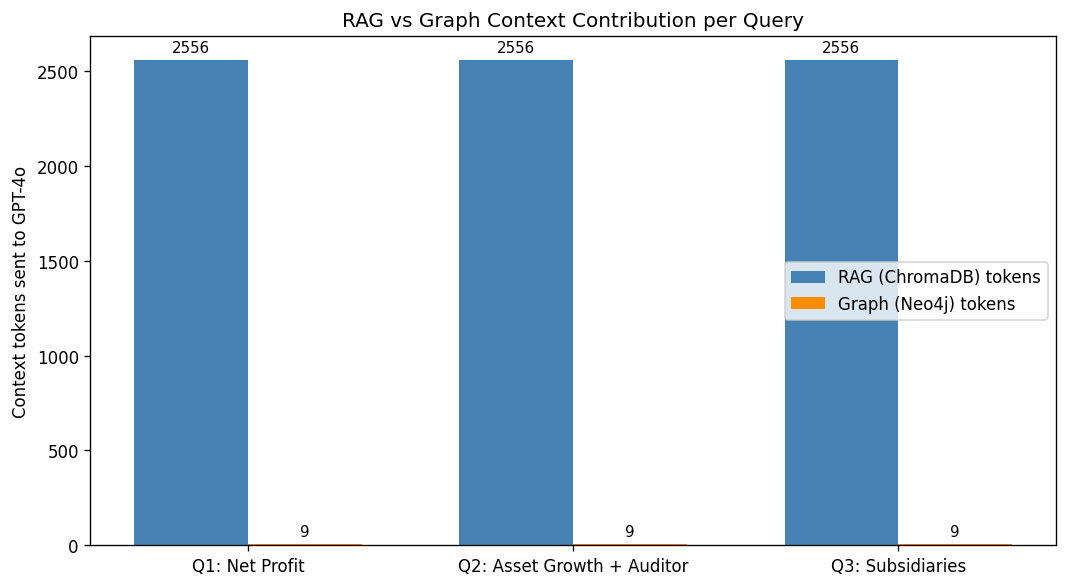

In [11]:
# Bar chart: context tokens contributed by RAG vs Graph for each query
queries_short = ["Q1: Net Profit", "Q2: Asset Growth + Auditor", "Q3: Subsidiaries"]
rag_tok   = [grag_result1["rag_tokens"],   grag_result2["rag_tokens"],   grag_result3["rag_tokens"]]
graph_tok = [grag_result1["graph_tokens"], grag_result2["graph_tokens"], grag_result3["graph_tokens"]]

x = range(len(queries_short))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar([i - width/2 for i in x], rag_tok,   width, label="RAG (ChromaDB) tokens",  color="steelblue")
bars2 = ax.bar([i + width/2 for i in x], graph_tok, width, label="Graph (Neo4j) tokens",   color="darkorange")

ax.set_xticks(list(x))
ax.set_xticklabels(queries_short, fontsize=10)
ax.set_ylabel("Context tokens sent to GPT-4o")
ax.set_title("RAG vs Graph Context Contribution per Query")
ax.legend()
ax.bar_label(bars1, padding=3, fontsize=9)
ax.bar_label(bars2, padding=3, fontsize=9)
plt.tight_layout()
plt.show()

## When to Use GraphRAG vs Plain RAG

| Scenario | Use Plain RAG | Use GraphRAG |
|----------|---------------|--------------|
| Single-document fact lookup | ✅ | ✅ |
| Multi-document comparison | ❌ Hard | ✅ |
| Year-over-year trends | ❌ Unreliable | ✅ |
| Relationship traversal (subsidiaries, auditors) | ❌ | ✅ |
| Free-form summary of narrative | ✅ | ✅ |
| Low-cost, fast prototype | ✅ | ❌ Higher upfront cost |

**GraphRAG is the right choice** when your users will ask about:
- Relationships between entities (audit, subsidiaries, board)
- Cross-document or cross-year comparisons
- Structured financial metrics (where a KG gives you exact values)

---

> **Next:** Section 06 wraps GraphRAG inside an **AI agent** that can decide *which* retrieval strategy to use based on the question — and also compute financial ratios on the fly.